In [2]:
from google.colab import files
uploaded = files.upload()

Saving clean_sentiment.csv - clean_sentiment.csv.csv to clean_sentiment.csv - clean_sentiment.csv (1).csv
Saving historical_data - historical_data.csv to historical_data - historical_data.csv


In [3]:
import pandas as pd

trades = pd.read_csv("historical_data - historical_data.csv")
sentiment = pd.read_csv("clean_sentiment.csv - clean_sentiment.csv.csv")

print(trades.shape)
print(sentiment.shape)

trades.head()

(211224, 11)
(2644, 3)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Direction,Closed PnL,Fee,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,Buy,0.00,0.345404,12/2/2024
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,Buy,0.00,0.005600,12/2/2024
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,Buy,0.00,0.050431,12/2/2024
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,Buy,0.00,0.050043,12/2/2024
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,Buy,0.00,0.003055,12/2/2024


In [4]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Direction,0
Closed PnL,0
Fee,0


In [5]:
sentiment.isnull().sum()

,0
date,0
classification,0
sentiment_group,0


In [6]:
trades['trade_date'] = pd.to_datetime(trades['trade_date'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [7]:
data = pd.merge(
    trades,
    sentiment[['date','sentiment_group']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Direction,Closed PnL,Fee,trade_date,date,sentiment_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,Buy,0.00,0.345404,2024-12-02,2024-12-02,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,Buy,0.00,0.005600,2024-12-02,2024-12-02,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,Buy,0.00,0.050431,2024-12-02,2024-12-02,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,Buy,0.00,0.050043,2024-12-02,2024-12-02,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,Buy,0.00,0.003055,2024-12-02,2024-12-02,Greed


In [8]:
daily_pnl = data.groupby(['Account','trade_date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,trade_date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000.000.000.000.000.000.000.000.000.000.000....
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000.000.000.000.000.000.000.000.000.000.000....
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000.000.000.000.000.000.000.000.000.000.000....
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,"-1,274.77-1,666.43-2,445.44-2,263.22-2,140.72-..."
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,64.44103.56103.5632.0632.062.9225.4413.58207.1...


In [10]:
data['Closed PnL'] = pd.to_numeric(data['Closed PnL'], errors='coerce')

In [11]:
data['win'] = data['Closed PnL'] > 0

win_rate = data.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.281037
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.441071
2,0x271b280974205ca63b716753467d5a371de622ab,0.299816
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.435880
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.509416


In [12]:
trades_per_day = data.groupby('trade_date').size()

trades_per_day.head()

,0
trade_date,
2023-05-01,3
2023-12-05,9
2023-12-14,11
2023-12-15,2
2023-12-16,3


In [15]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [13]:
data['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [20]:
features = data.groupby('Account').agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'win':'mean'
}).reset_index()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = features[['Closed PnL','Size USD','win']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
features['segment'] = kmeans.fit_predict(X_scaled)

features.head()

,Account,Closed PnL,Size USD,win,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,148009.34,16159.576734,0.281037,1
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,54096.21,1653.226327,0.441071,2
2,0x271b280974205ca63b716753467d5a371de622ab,15241.00,8893.000898,0.299816,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,128021.08,507.626933,0.435880,2
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,103567.40,3138.894782,0.509416,2


In [25]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.7 MB/s eta 0:00:00


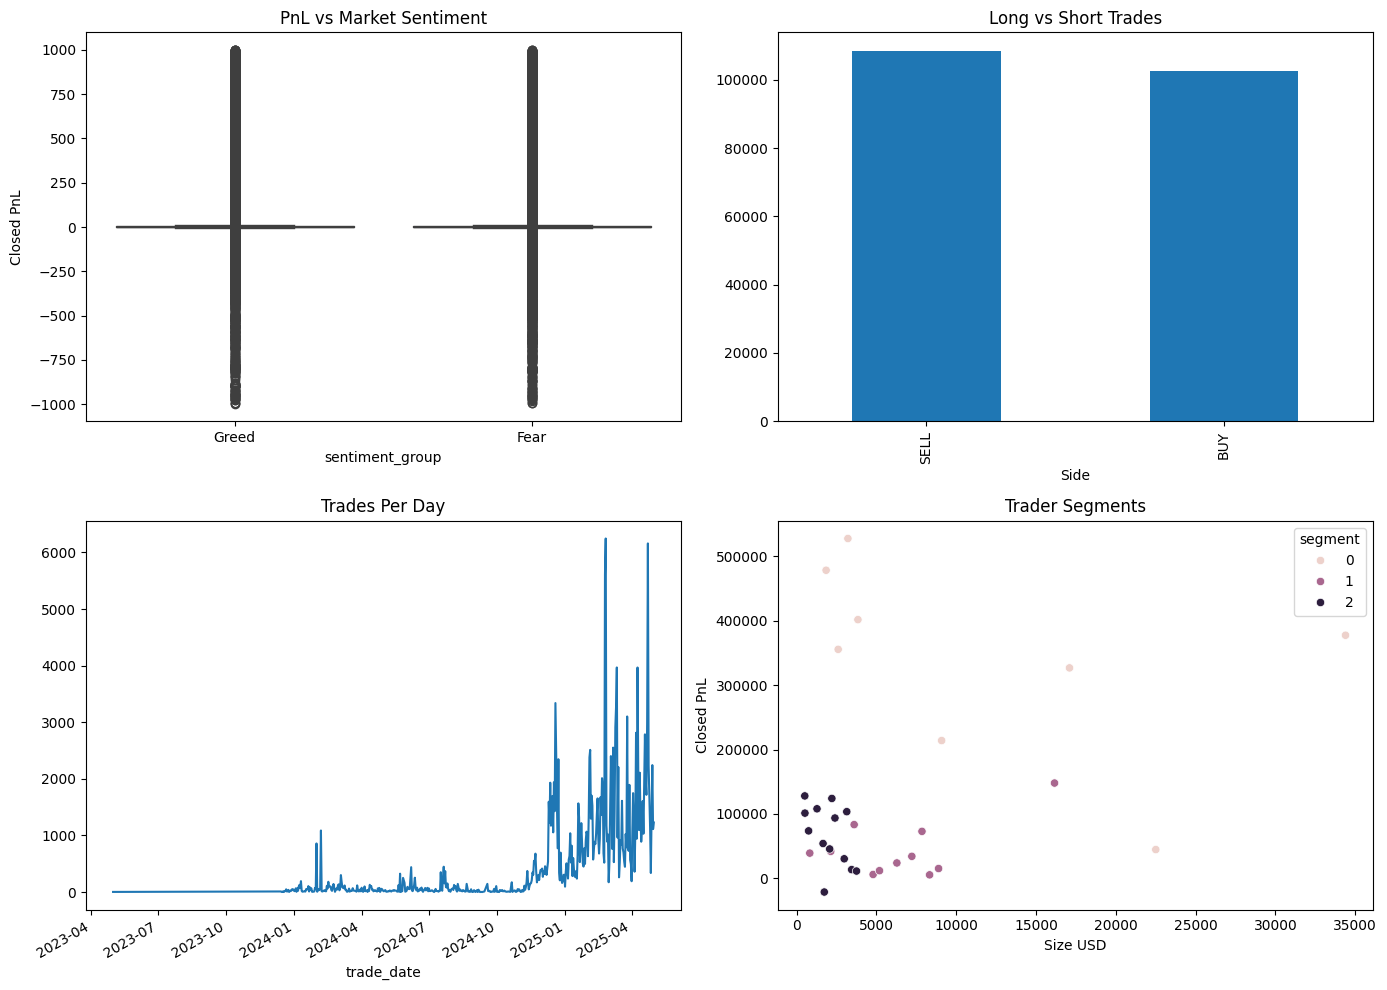

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Chart 1: PnL vs Sentiment
sns.boxplot(x='sentiment_group', y='Closed PnL', data=data, ax=axes[0,0])
axes[0,0].set_title("PnL vs Market Sentiment")

# Chart 2: Long vs Short
data['Side'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Long vs Short Trades")

# Chart 3: Trades Per Day
trades_per_day = data.groupby('trade_date').size()
trades_per_day.plot(ax=axes[1,0])
axes[1,0].set_title("Trades Per Day")

# Chart 4: Trader Segments
sns.scatterplot(x='Size USD', y='Closed PnL', hue='segment', data=features, ax=axes[1,1])
axes[1,1].set_title("Trader Segments")

plt.tight_layout()
plt.show()

In [28]:
fig.savefig("trader_dashboard.png")